In [76]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn import functional as F

from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [77]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [78]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="D:\\ct_reconstruction_dataset",
    sinogram_shape=(512, 365),
    image_shape=(256, 256),
    parts_len={"train": 206143, "validation": 25767, "test": 25769},
    impl="skimage",
)

test_dataset = dataset.create_torch_dataset(part="test")

In [79]:
batch_size = 8

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [80]:
class UnetGenerator(nn.Module):
    """Unet-like Encoder-Decoder model"""

    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
            )

        # Encoder
        self.enc1 = conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)  # 512x365 -> 256x182
        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)  # 256x182 -> 128x91
        self.enc3 = conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)  # 128x91 -> 64x45
        self.enc4 = conv_block(128, 256)

        # Bottleneck
        self.bottleneck = conv_block(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) # 64x45 -> 128x90(91)
        self.dec3 = conv_block(256 + 128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # 128x91 -> 256x182
        self.dec2 = conv_block(128 + 64, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # 256x182 -> 512x364(365)
        self.dec1 = conv_block(64 + 32, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

        self.resize = nn.AdaptiveAvgPool2d((256, 256))

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(e4)

        d3 = self.up3(b)
        d3 = F.interpolate(d3, size=e3.shape[2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        # d2 = F.interpolate(d2, size=e2.shape[2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=e1.shape[2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = self.final(d1)
        return self.resize(out)

In [81]:
def load_generator(checkpoint_path, generator, device="cuda"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator_state_dict"])
    generator.to(device)
    generator.eval()

    return generator

In [82]:
generator = UnetGenerator().to(device)
generator = load_generator("checkpoints/checkpoint_39.pt", generator, device)

In [85]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of trainable parameters:", count_parameters(generator))

Number of trainable parameters: 7336545


In [ ]:
mse_criterion = nn.MSELoss()

generator.eval()
mse_test_loss = 0.0
ssim_val_loss = 0.0
with torch.no_grad():
    for sino, img in test_loader:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)
        img = img.unsqueeze(1).to(device, non_blocking=True)

        output = generator(sino)
        loss = mse_criterion(output, img)
        mse_test_loss += loss.item()

        output_np = output.squeeze().cpu().numpy()
        img_np = img.squeeze().cpu().numpy()
        ssim_value = ssim(
            img_np, output_np, data_range=img_np.max() - img_np.min()
        )
        # Ensure we accumulate only the scalar score.
        if isinstance(ssim_value, (tuple, list)):
            ssim_value = ssim_value[0]
        ssim_val_loss += float(ssim_value)

    mse_test_loss /= len(test_loader)
    ssim_val_loss /= len(test_loader)

print(
    f"Val Loss: {mse_test_loss:.6f} | "
    f"Val SSIM: {ssim_val_loss:.4f}"
)

Val Loss: 0.000948 | Val SSIM: 0.9020


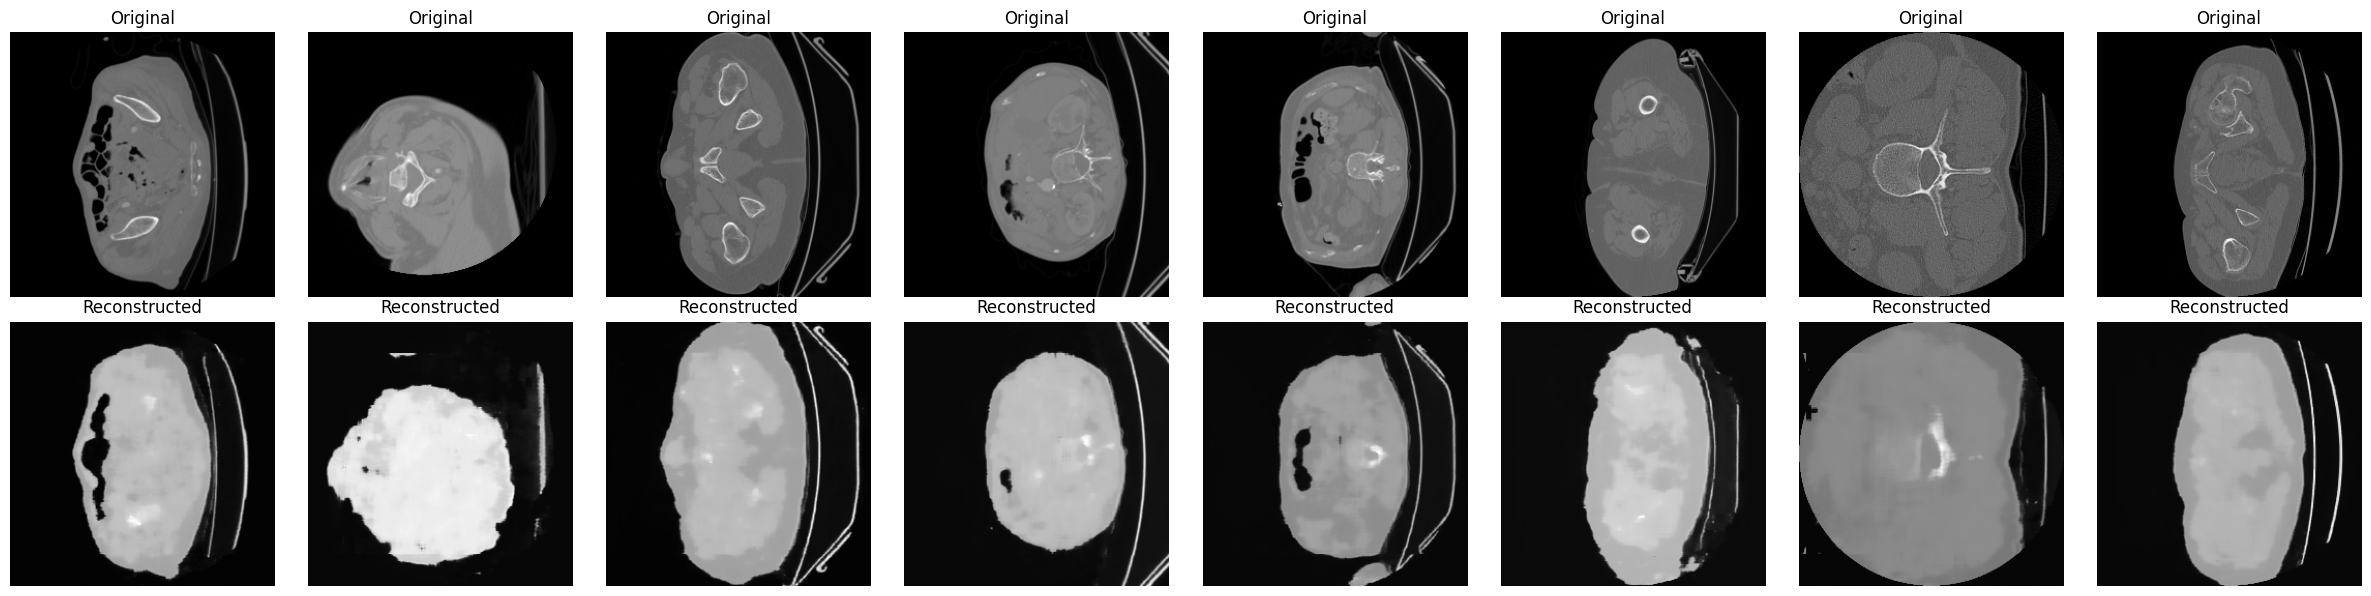

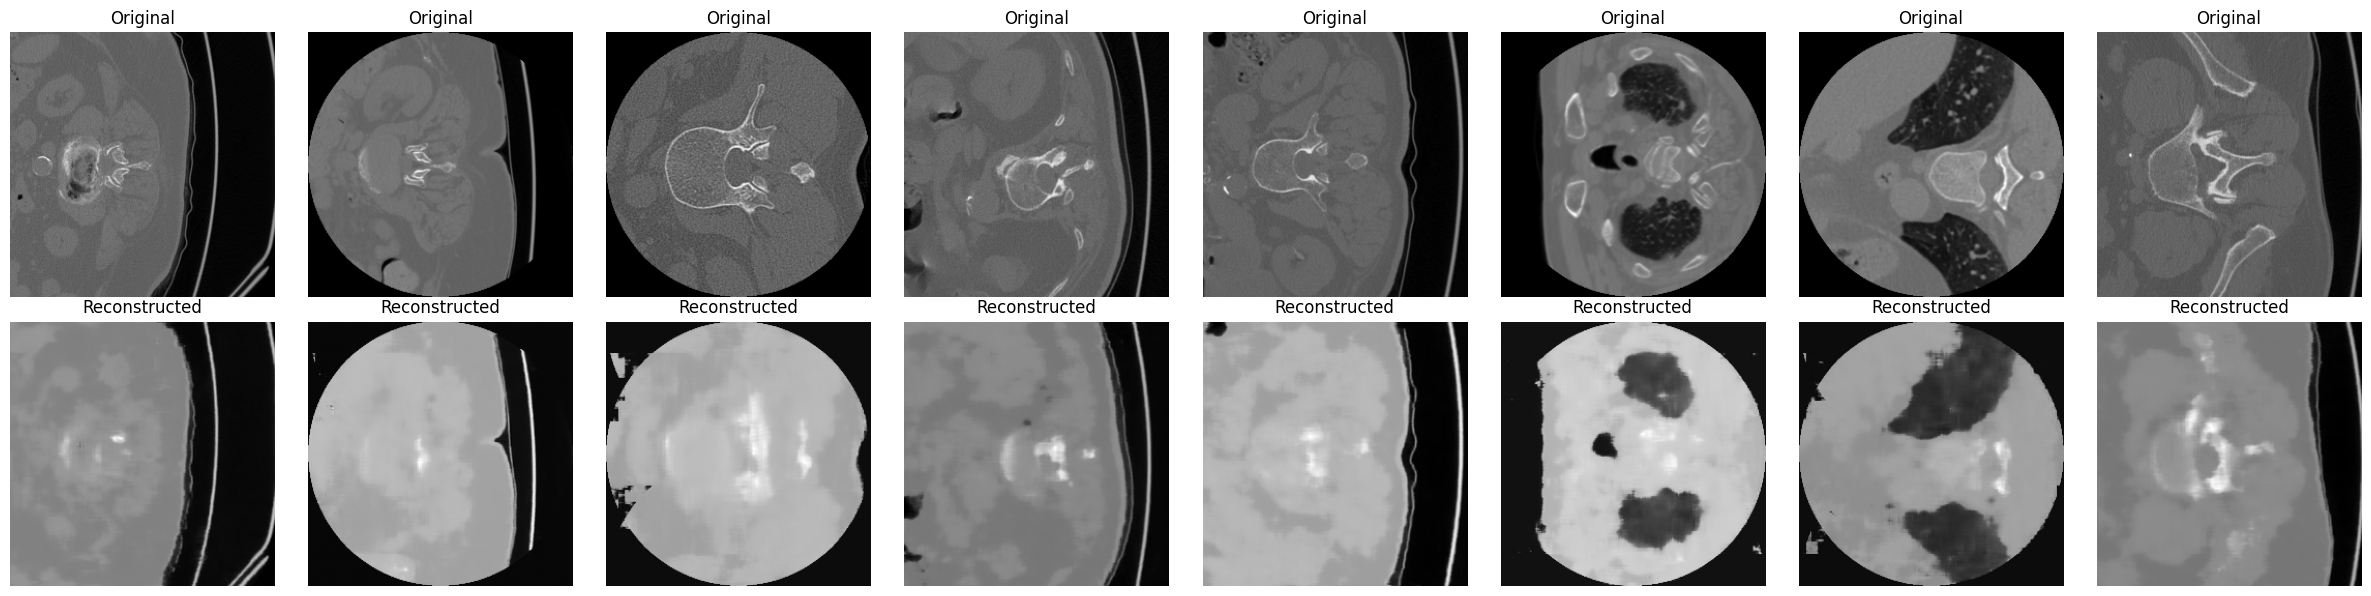

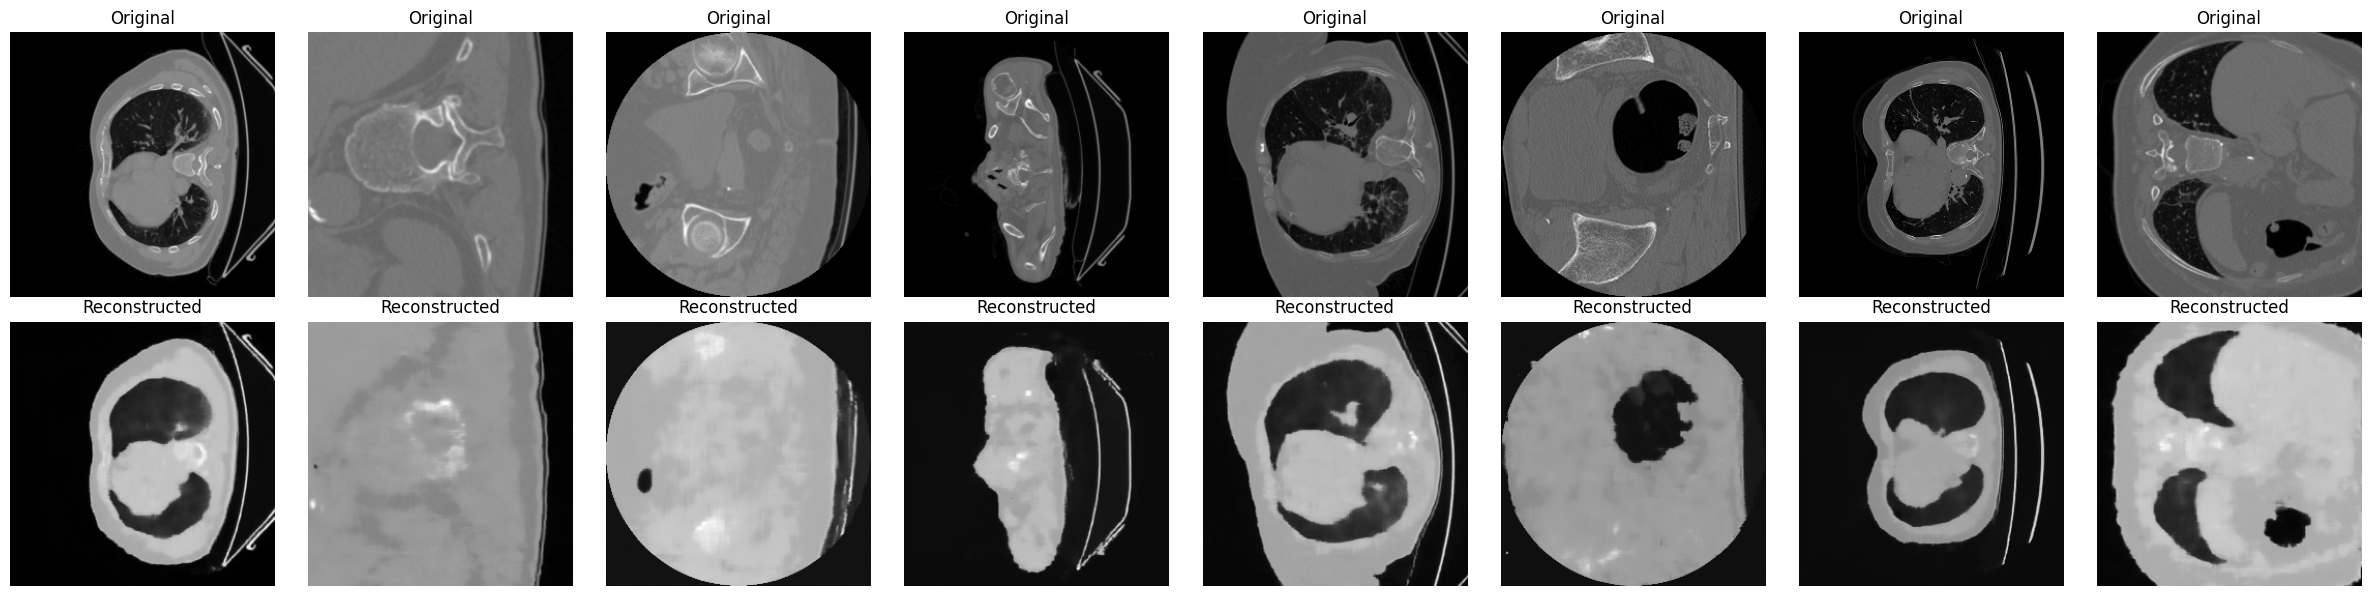

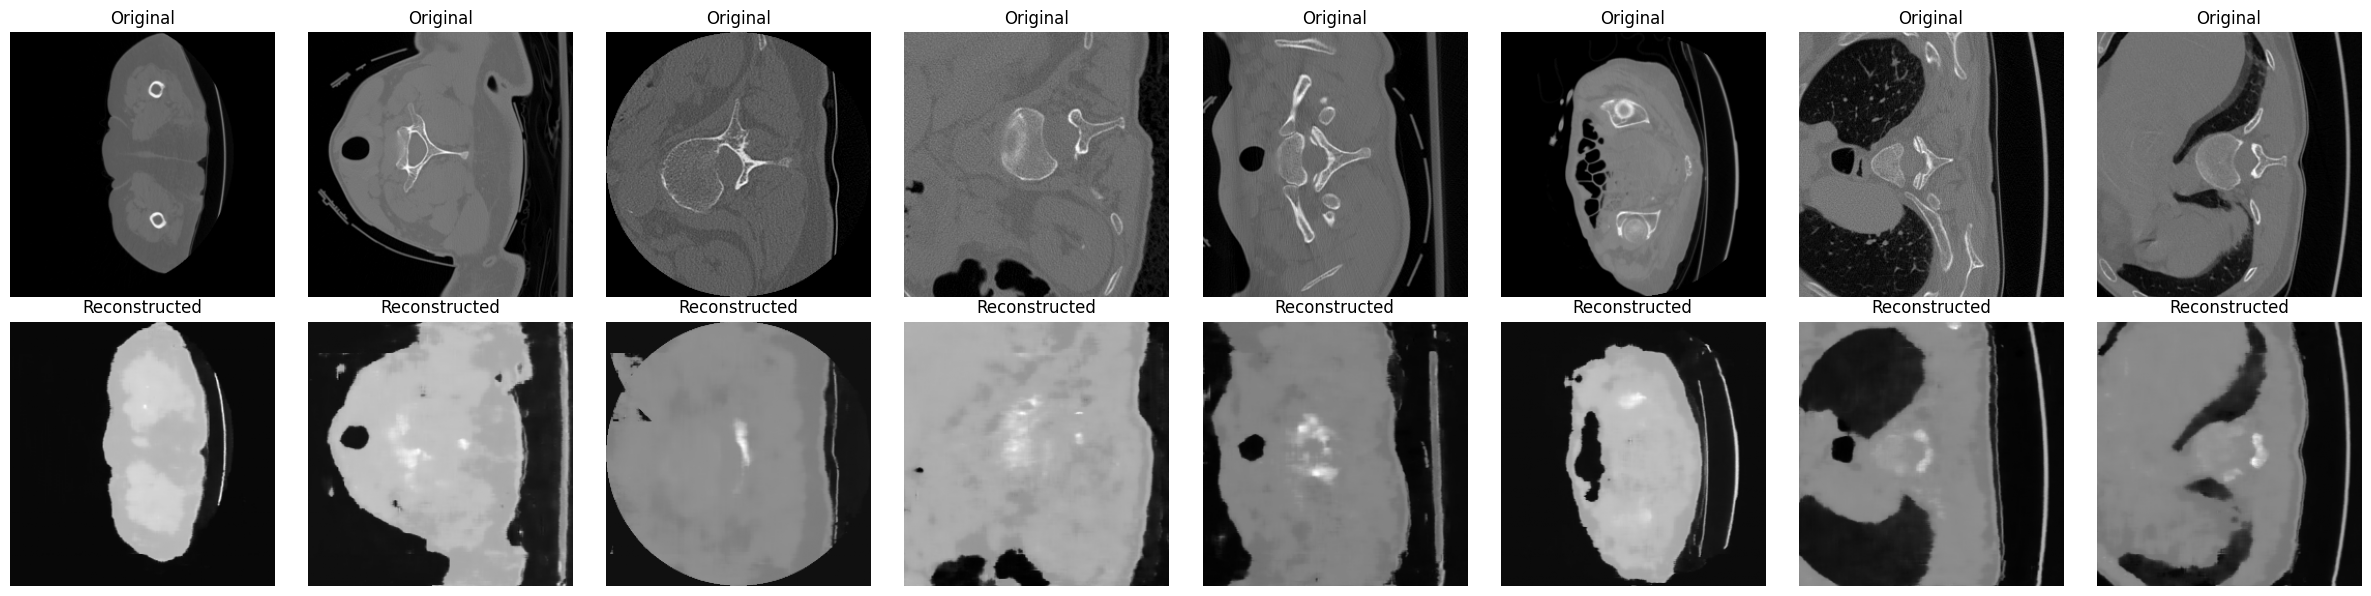

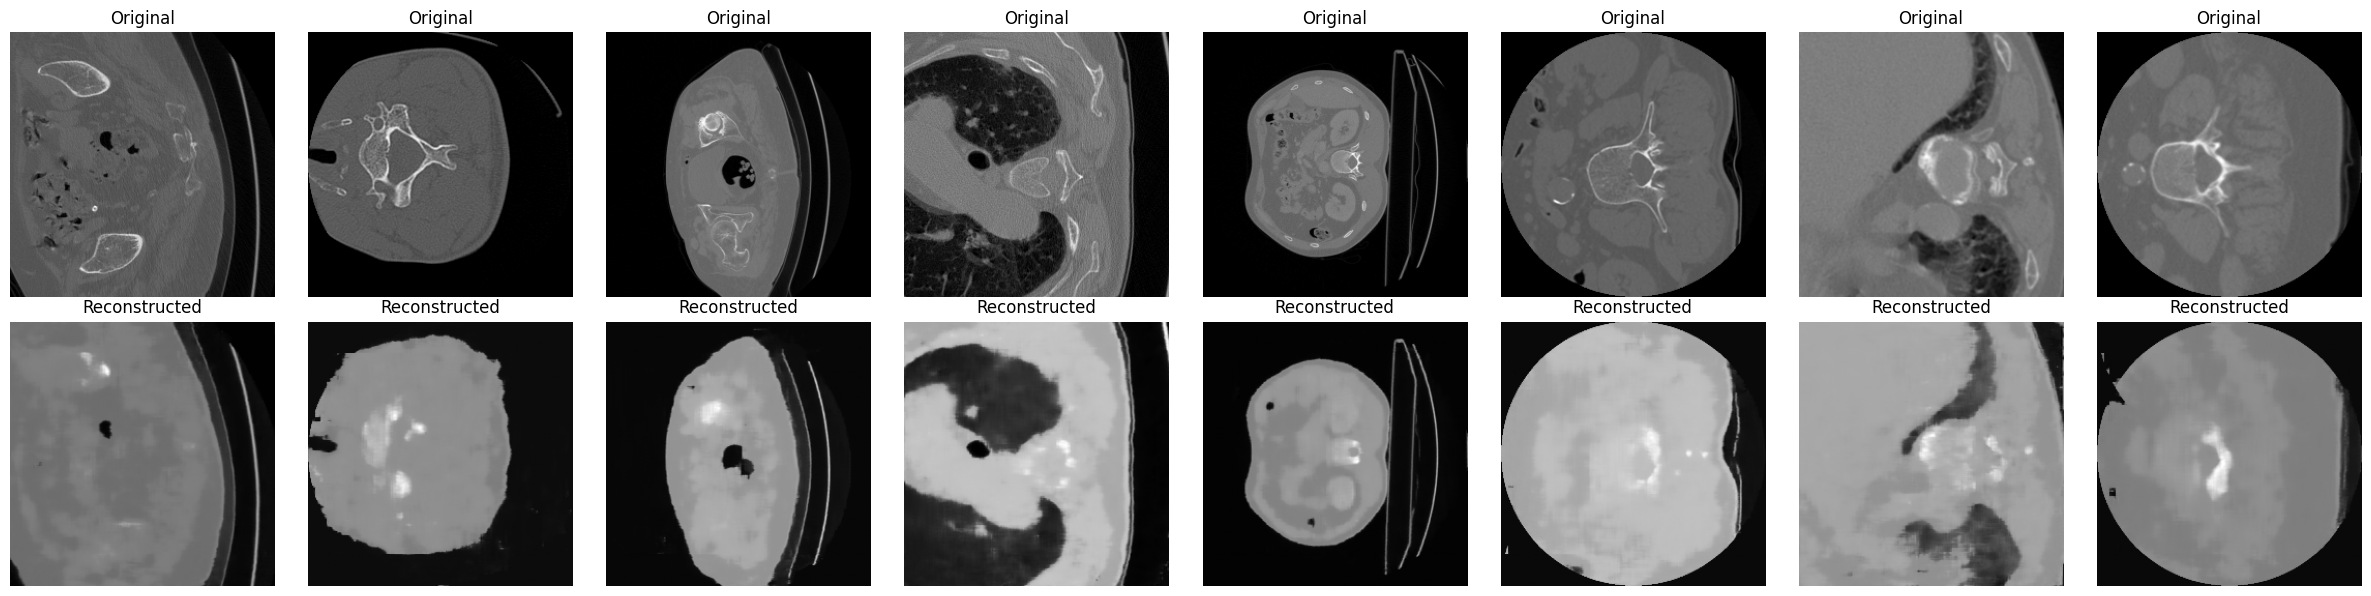

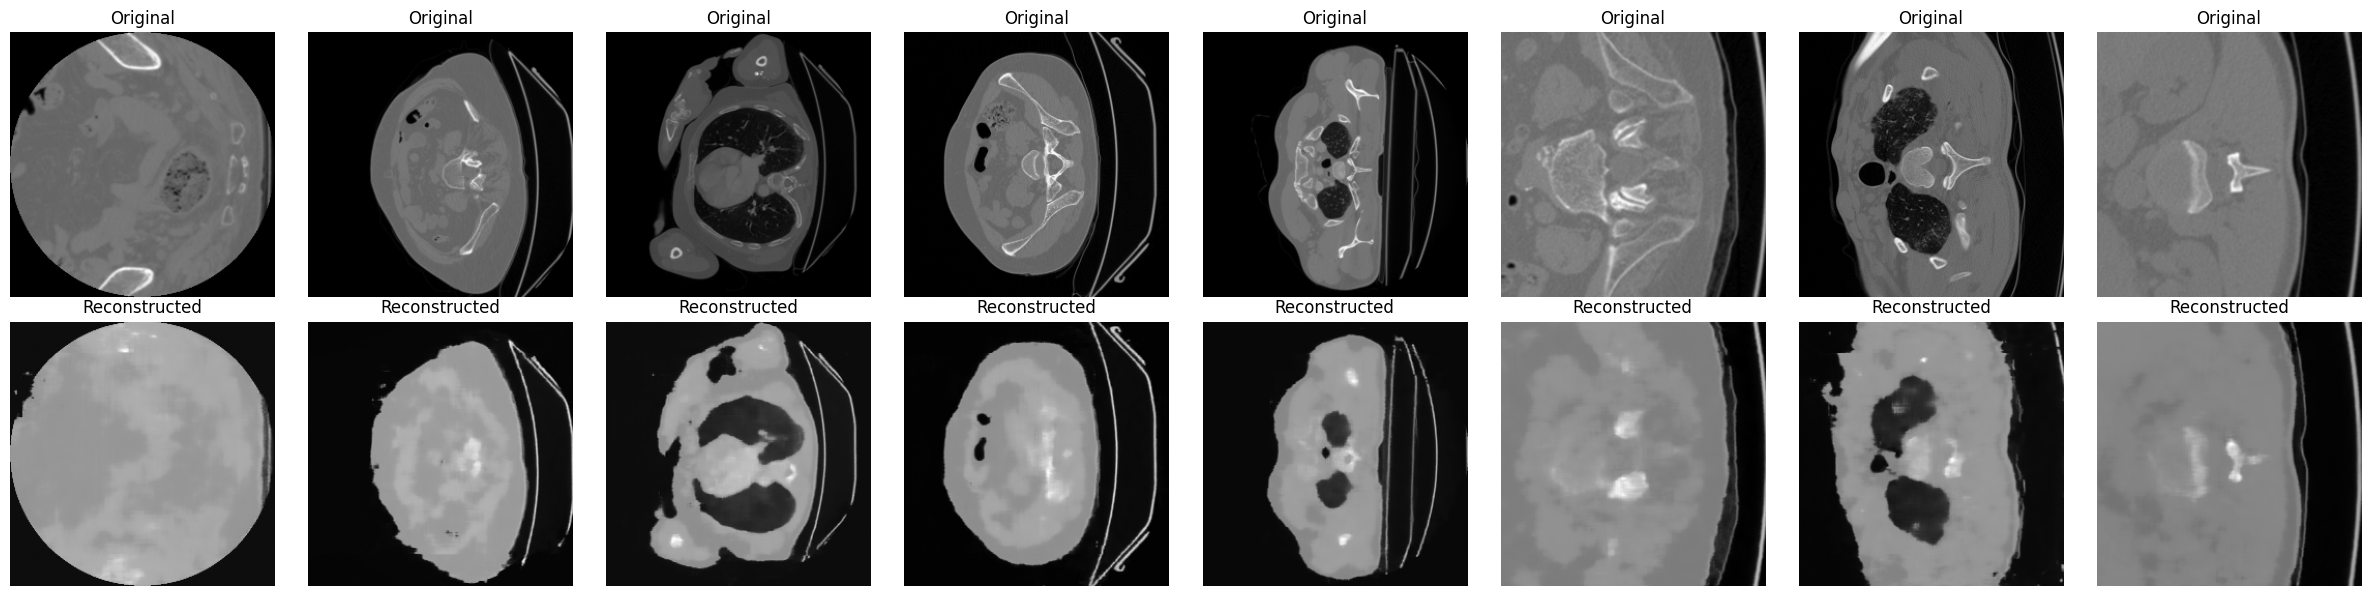

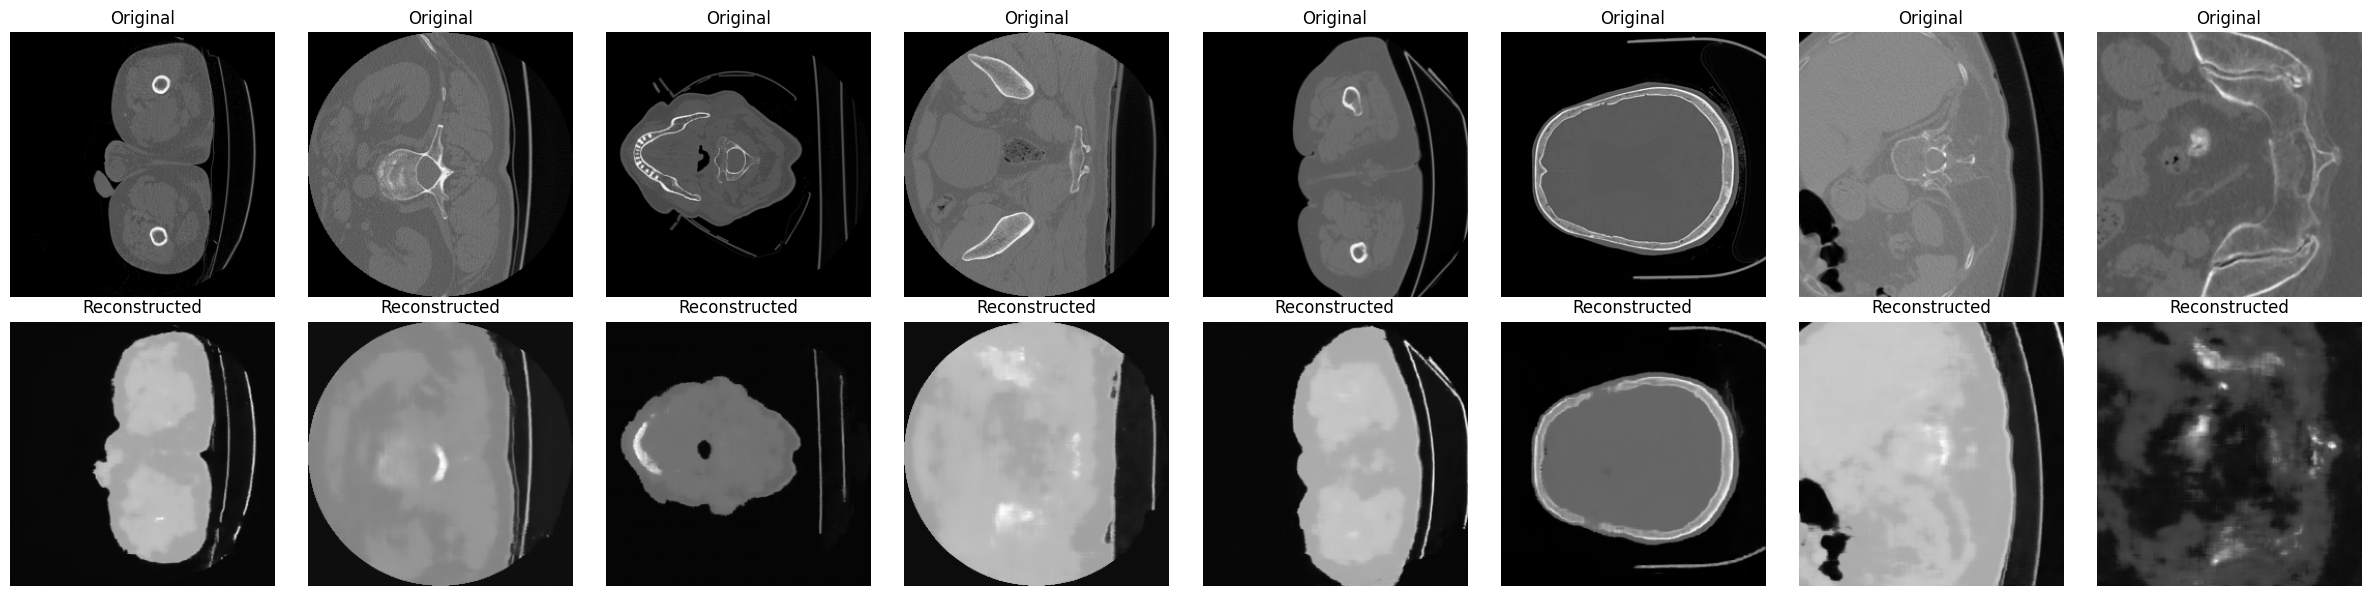

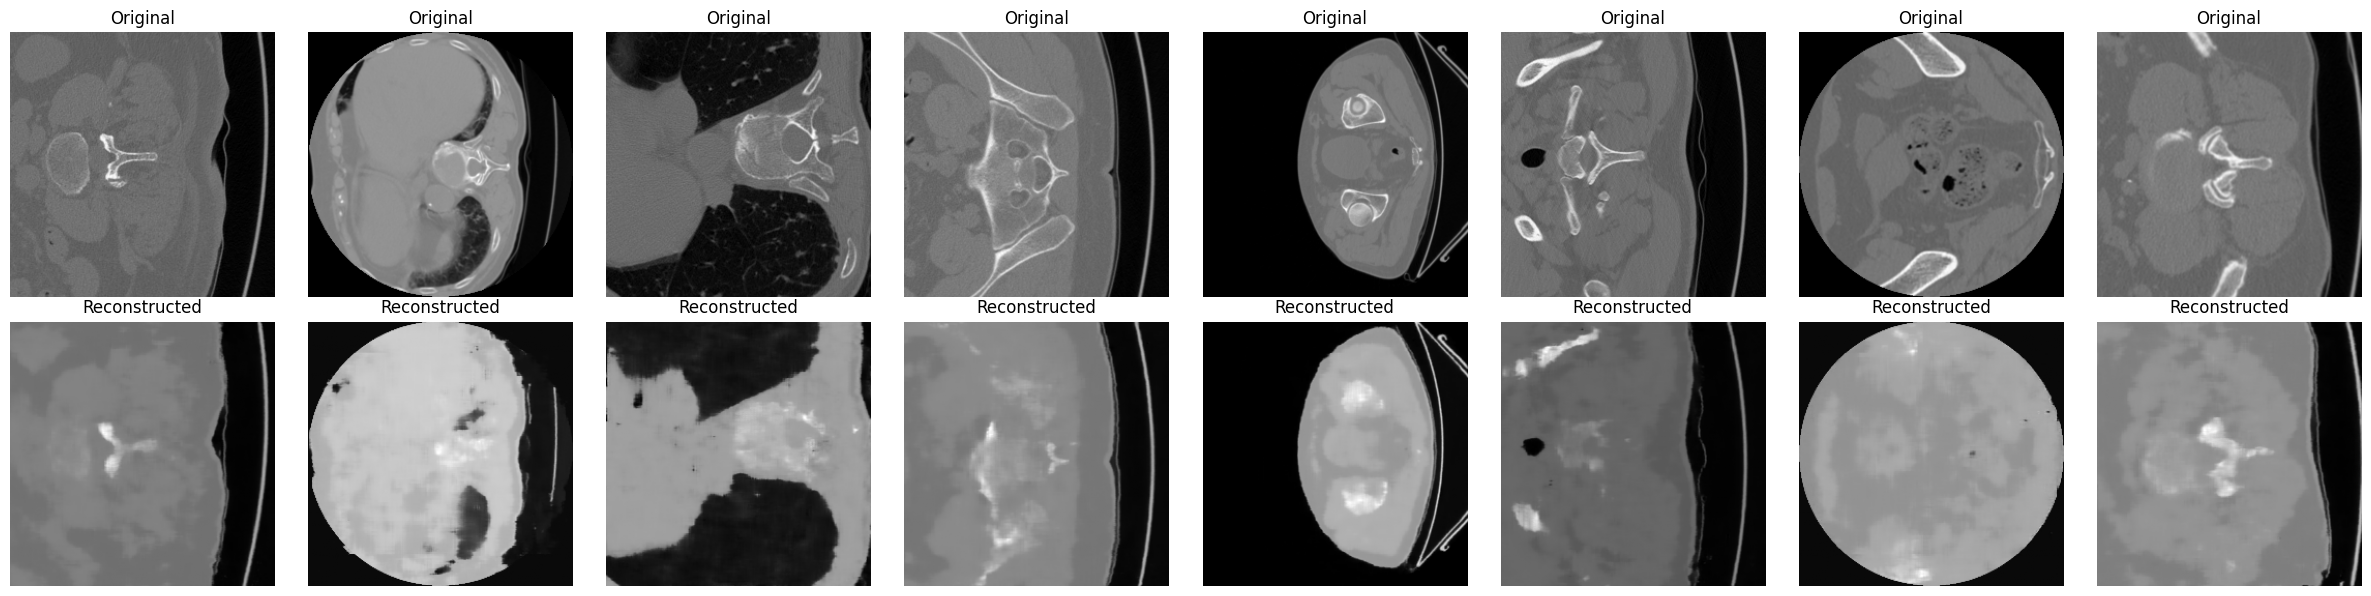

In [ ]:
import matplotlib.pyplot as plt

def show_reconstructed_images(model, dataloader, device, num_images=5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for sino, img in dataloader:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            output = model(sino)

            batch_size = img.size(0)
            n = min(batch_size, num_images - shown)

            # Create a figure with 2 rows: original and reconstructed
            fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(3 * n, 6))

            for i in range(n):
                # Original image
                axes[0, i].imshow(img[i].cpu().numpy().squeeze(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")

                # Reconstructed image
                axes[1, i].imshow(output[i].cpu().numpy().squeeze(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")

            plt.tight_layout()
            plt.show()

            shown += n
            if shown >= num_images:
                break

show_reconstructed_images(generator, test_loader, device, num_images=64)

In [ ]:
# import os

# # Save the model
# model_name = "pix2pix.pth"
# model_directory = "../models"
# model_path = f"{model_directory}/{model_name}"

# os.makedirs(model_directory, exist_ok=True)

# if os.path.exists(model_path):
#     print(f"Model {model_name} already exists.")
# else:
#     print(f"Saving model to {model_path}")
#     torch.save(generator.state_dict(), model_path)